<a href="https://colab.research.google.com/github/Deepika-J2106/sentiment-analysis-nlp/blob/main/Sentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [19]:
import pandas as pd
df = pd.read_csv('IMDB Dataset.csv')
df.info()
print(df['sentiment'].value_counts())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [20]:
print(df['review'][0])
print('Length of first element:',len(df['review'][0]))

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

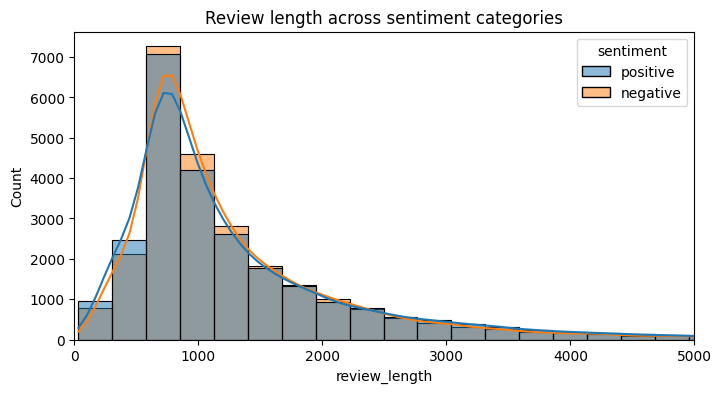

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
df["review_length"] = df['review'].apply(len)
plt.figure(figsize = (8,4))
sns.histplot(data = df, x = "review_length", hue = "sentiment" , bins = 50, kde = True)
plt.title("Review length across sentiment categories")
plt.xlim(0,5000)
plt.show()

In [37]:
from collections import Counter
import re
def get_top_words(text_series,n=15):
  all_words = ' '.join(text_series).lower()
  words = re.findall(r'\b[a-z]+\b', all_words)
  return Counter(words).most_common(n)

print("Top words of positive reviews are: ", get_top_words(df[df['sentiment'] == 'positive']['review']))
print("Top words of negative reviews are: ", get_top_words(df[df['sentiment'] == 'negative']['review']))


Top words of positive reviews are:  [('the', 341281), ('and', 176634), ('a', 164323), ('of', 152105), ('to', 131322), ('is', 111830), ('in', 99250), ('br', 97954), ('it', 95133), ('i', 81997), ('this', 69648), ('that', 69593), ('s', 64675), ('as', 51106), ('with', 45718)]
Top words of negative reviews are:  [('the', 326712), ('a', 158647), ('and', 147807), ('of', 137305), ('to', 136802), ('br', 103997), ('is', 99252), ('it', 95724), ('i', 93636), ('in', 87531), ('this', 81354), ('that', 74286), ('s', 60333), ('was', 52269), ('movie', 50117)]


In [39]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = re.sub(r'<.>*?>',' ', text)
  text = text.lower()
  text = re.sub(r'[^a-z\s]','', text)
  words = text.split()
  words = [w for w in words if w not in stop_words]
  return ' '.join(words)

df['cleaned_review'] = df['review'].apply(clean_text)
print(df[['review','cleaned_review']].head(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   

                                      cleaned_review  
0  one reviewers mentioned watching oz episode yo...  
1  wonderful little production br br filming tech...  


In [42]:
print('Top words in cleaned positive review: ', df[df["sentiment"] == 'positive']["cleaned_review"])
print('Top words in cleaned negative review: ', df[df["sentiment"] == 'negative']["cleaned_review"])

Top words in cleaned positive review:  0        one reviewers mentioned watching oz episode yo...
1        wonderful little production br br filming tech...
2        thought wonderful way spend time hot summer we...
4        petter matteis love time money visually stunni...
5        probably alltime favorite movie story selfless...
                               ...                        
49983    loved fan original series always wondered back...
49985    imaginary heroes clearly best film year comple...
49989    got one weeks ago love modern light filled tru...
49992    john garfield plays marine blinded grenade fig...
49995    thought movie right good job wasnt creative or...
Name: cleaned_review, Length: 25000, dtype: object
Top words in cleaned negative review:  3        basically theres family little boy jake thinks...
7        show amazing fresh innovative idea first aired...
8        encouraged positive comments film looking forw...
10       phil alien one quirky films humour b